# LUNA16 First Batch GT Alignment

This notebook visualizes the first SCPMNet batches for LUNA16 and compares:

- the current dataset tensor after `normalize_ct(..., clip=(-1000, 400))`
- the display used by the older notebook, `(image + 1) / 2`
- the reconstructed preprocessed LUNA16 uint8-like image, expected in `[0, 255]`

Use this to verify whether the LUNA16 batch is being scaled as intended.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Circle

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'src' / 'det' / 'SCPMNet').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.det.SCPMNet.datamodule import SCPMDataModule
from src.det.SCPMNet.dataset import load_volume, normalize_ct


In [18]:
CSV_PATH = '/Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed/cv_splits/luna16_fold0.csv'
DATA_ROOT = '/Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed'

SPLIT = 'train'  # train, val, or test_crop
BATCH_SIZE = 2
NUM_WORKERS = 0
CROP_SIZE = (96, 96, 96)
SAMPLES_PER_VOLUME = 4
POSITIVE_CROP_PROB = 1.0
CLIP = (-1000.0, 400.0)

torch.manual_seed(233)
np.random.seed(233)


In [19]:
dm = SCPMDataModule(
    csv_path=CSV_PATH,
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    crop_size=CROP_SIZE,
    samples_per_volume=SAMPLES_PER_VOLUME,
    clip=CLIP,
    positive_crop_prob=POSITIVE_CROP_PROB,
    mask_path_column=None,
    skip_missing_images=True,
    test_full_volume=False,
    sliding_window_stride=(24, 24, 24),
)

if SPLIT in ('train', 'val'):
    dm.setup('fit')
    loader = dm.train_dataloader() if SPLIT == 'train' else dm.val_dataloader()
else:
    dm.setup('test')
    loader = dm.test_dataloader()

it = iter(loader)
batches = [next(it) for _ in range(3)]
batch = batches[0]
images = batch['image'].cpu().numpy()[:, 0]
annots = batch['annot'].cpu().numpy()
seriesuids = batch['seriesuid']
origins = batch.get('origin')
origins = origins.cpu().numpy() if origins is not None else None

print('Batch image shape:', images.shape)
print('Batch annot shape:', annots.shape)
print('Seriesuids:', seriesuids)
for i, sid in enumerate(seriesuids):
    valid = annots[i, :, 3] > 0
    print(i, sid, 'origin:', None if origins is None else origins[i], 'valid GT:', int(valid.sum()), annots[i, valid])


Batch image shape: (2, 96, 96, 96)
Batch annot shape: (2, 1, 4)
Seriesuids: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.946129570505893110165820050204', '1.3.6.1.4.1.14519.5.2.1.6279.6001.164988920331211858091402361989']
0 1.3.6.1.4.1.14519.5.2.1.6279.6001.946129570505893110165820050204 origin: [ 64.  10. 185.] valid GT: 1 [[29.459816 44.284195 59.70877   4.530825]]
1 1.3.6.1.4.1.14519.5.2.1.6279.6001.164988920331211858091402361989 origin: [82.  0. 15.] valid GT: 1 [[65.37688   49.51887   52.186943   3.4543035]]


In [20]:
def pct(values):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]
    return np.percentile(values, [0, 0.1, 1, 50, 99, 99.9, 100])

def denorm_current_to_unit(image):
    # This is what visualize_first_batch_gt_alignment.ipynb used.
    return np.clip((image + 1.0) / 2.0, 0.0, 1.0)

def invert_current_normalization(image, clip=CLIP):
    # Inverts normalize_ct: norm = ((raw - low) / (high - low)) * 2 - 1.
    low, high = clip
    return ((image + 1.0) / 2.0) * (high - low) + low

def luna_uint8_display_from_current(image):
    raw_est = invert_current_normalization(image)
    return np.clip(raw_est / 255.0, 0.0, 1.0)

for i, image in enumerate(images):
    raw_est = invert_current_normalization(image)
    print('\nSample', i, seriesuids[i])
    print('current normalized tensor percentiles:', [round(float(x), 4) for x in pct(image)])
    print('raw values reconstructed from current normalization:', [round(float(x), 2) for x in pct(raw_est)])
    print('old notebook display (image+1)/2 percentiles:', [round(float(x), 4) for x in pct(denorm_current_to_unit(image))])
    print('uint8 display raw/255 percentiles:', [round(float(x), 4) for x in pct(luna_uint8_display_from_current(image))])



Sample 0 1.3.6.1.4.1.14519.5.2.1.6279.6001.946129570505893110165820050204
current normalized tensor percentiles: [0.4286, 0.4286, 0.4286, 0.49, 0.7243, 0.7929, 0.7929]
raw values reconstructed from current normalization: [0.0, 0.0, 0.0, 43.0, 207.0, 255.0, 255.0]
old notebook display (image+1)/2 percentiles: [0.7143, 0.7143, 0.7143, 0.745, 0.8621, 0.8964, 0.8964]
uint8 display raw/255 percentiles: [0.0, 0.0, 0.0, 0.1686, 0.8118, 1.0, 1.0]

Sample 1 1.3.6.1.4.1.14519.5.2.1.6279.6001.164988920331211858091402361989
current normalized tensor percentiles: [0.4286, 0.4286, 0.4286, 0.4843, 0.7429, 0.79, 0.7929]
raw values reconstructed from current normalization: [0.0, 0.0, 0.0, 39.0, 220.0, 253.0, 255.0]
old notebook display (image+1)/2 percentiles: [0.7143, 0.7143, 0.7143, 0.7421, 0.8714, 0.895, 0.8964]
uint8 display raw/255 percentiles: [0.0, 0.0, 0.0, 0.1529, 0.8627, 0.9922, 1.0]


In [21]:
# Direct raw-volume check for the first series in the batch.
ds = dm.train_ds if SPLIT == 'train' else (dm.val_ds if SPLIT == 'val' else dm.test_ds)
seriesuid, rows = ds.groups[0]
image_path = Path(rows.iloc[0]['_resolved_image_path'])
raw_volume = load_volume(image_path)
norm_volume = normalize_ct(raw_volume, CLIP)

print('First dataset series:', seriesuid)
print('Resolved image path:', image_path)
print('Raw volume shape:', raw_volume.shape, 'dtype:', raw_volume.dtype)
print('Raw volume percentiles:', [round(float(x), 3) for x in pct(raw_volume)])
print('Raw volume in 0..255?', float(np.nanmin(raw_volume)) >= 0.0 and float(np.nanmax(raw_volume)) <= 255.0)
print('After current normalize_ct percentiles:', [round(float(x), 4) for x in pct(norm_volume)])


First dataset series: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
Resolved image path: /Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860_volume.nii.gz
Raw volume shape: (336, 243, 328) dtype: float32
Raw volume percentiles: [0.0, 0.0, 0.0, 0.0, 227.0, 255.0, 255.0]
Raw volume in 0..255? True
After current normalize_ct percentiles: [0.4286, 0.4286, 0.4286, 0.4286, 0.7529, 0.7929, 0.7929]


In [22]:
def valid_annots(sample_annots):
    return sample_annots[sample_annots[:, 3] > 0]

def plot_gt(ax, sample_annots, z):
    for n, (cz, cy, cx, radius) in enumerate(valid_annots(sample_annots), start=1):
        dz = abs(float(cz) - z)
        slice_radius = max(float(radius) ** 2 - dz ** 2, 0.0) ** 0.5
        if slice_radius <= 0:
            continue
        ax.add_patch(Circle((float(cx), float(cy)), max(slice_radius, 1.5), fill=False, color='lime', linewidth=1.8))
        ax.scatter([float(cx)], [float(cy)], marker='+', c='yellow', s=55, linewidths=1.8)
        ax.text(float(cx) + 2, float(cy) + 2, str(n), color='yellow', fontsize=9)

def default_z(sample_idx):
    gt = valid_annots(annots[sample_idx])
    return int(round(gt[0, 0])) if len(gt) else images[sample_idx].shape[0] // 2

def plot_sample_slice(sample_idx=0, z=None, figsize=(16, 5)):
    image = images[sample_idx]
    sample_annots = annots[sample_idx]
    if z is None:
        z = default_z(sample_idx)
    z = int(np.clip(z, 0, image.shape[0] - 1))

    panels = [
        ('Current tensor, vmin=-1 vmax=1', image[z], -1, 1),
        ('Old notebook display: (image+1)/2', denorm_current_to_unit(image[z]), 0, 1),
        ('LUNA uint8 display: reconstructed raw/255', luna_uint8_display_from_current(image[z]), 0, 1),
    ]
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for ax, (title, arr, vmin, vmax) in zip(axes, panels):
        ax.imshow(arr, cmap='gray', vmin=vmin, vmax=vmax)
        plot_gt(ax, sample_annots, z)
        ax.set_title(title)
        ax.set_xlim(0, image.shape[2] - 1)
        ax.set_ylim(image.shape[1] - 1, 0)
        ax.set_axis_off()
    fig.suptitle(f'sample={sample_idx} series={seriesuids[sample_idx]} z={z}')
    plt.tight_layout()
    plt.show()


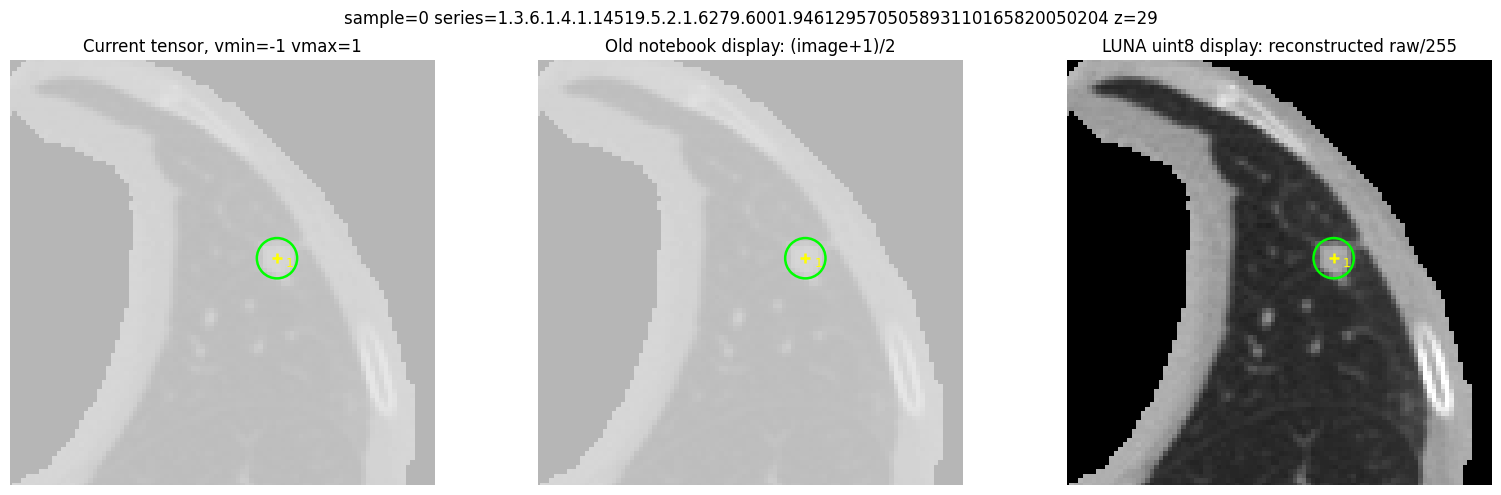

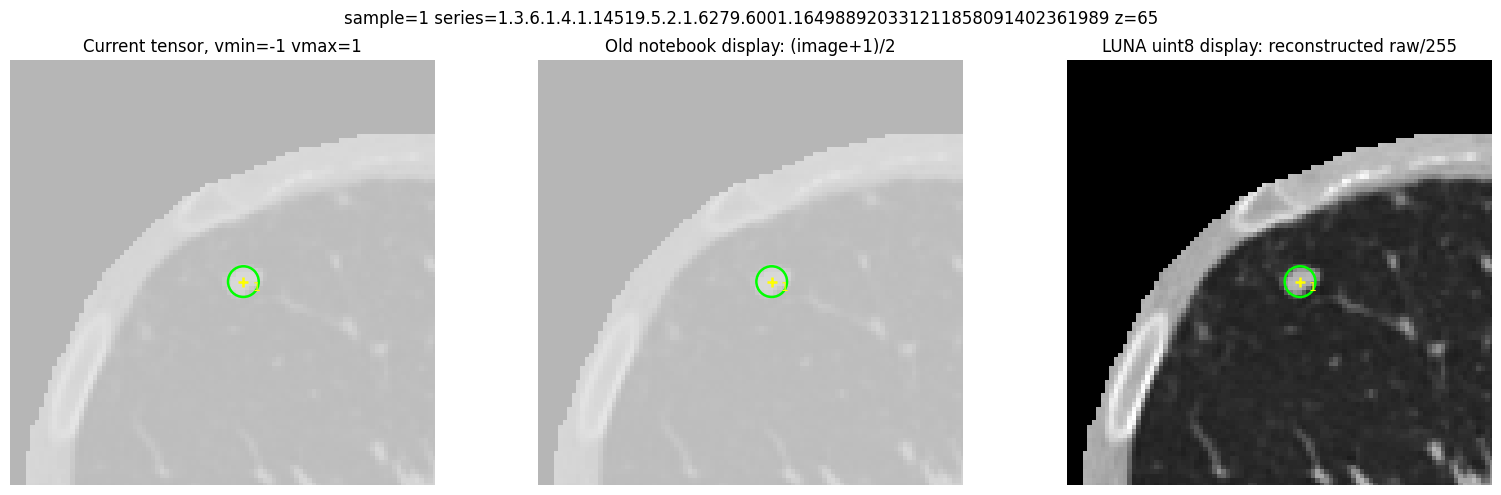

In [23]:
for sample_idx in range(len(seriesuids)):
    plot_sample_slice(sample_idx=sample_idx, z=default_z(sample_idx))


In [24]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    sample_widget = widgets.IntSlider(value=0, min=0, max=len(seriesuids) - 1, step=1, description='sample')
    z_widget = widgets.IntSlider(value=default_z(0), min=0, max=images[0].shape[0] - 1, step=1, description='z')

    def update_z_range(*_):
        sample_idx = sample_widget.value
        z_widget.max = images[sample_idx].shape[0] - 1
        z_widget.value = default_z(sample_idx)

    sample_widget.observe(update_z_range, names='value')
    ui = widgets.HBox([sample_widget, z_widget])
    out = widgets.interactive_output(plot_sample_slice, {'sample_idx': sample_widget, 'z': z_widget})
    display(ui, out)
except ImportError:
    print('ipywidgets is not installed. Use plot_sample_slice(sample_idx=0, z=48) manually.')


Output()

## Expected Interpretation

If LUNA16 preprocessed volumes are already in `[0, 255]`, the reconstructed raw values should also be in `[0, 255]` and the current normalized tensor should sit roughly in `[0.43, 0.79]`. In that case, the `old notebook display` panel will look brighter/compressed compared with the `raw/255` panel.